In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the built-in dataset
df = sns.load_dataset('titanic')

# Requirement: Handle missing values (imputation) [cite: 10]
# Fill missing Age with the mean [cite: 14, 39]
df["age"].fillna(df["age"].mean(), inplace=True)

# Requirement: Drop irrelevant columns like 'deck' (the built-in version uses 'deck' instead of 'Cabin') [cite: 15, 41]
df.drop(columns=["deck"], inplace=True)

# Requirement: Use groupby for deeper insights [cite: 10]
embark_survival = df.groupby("embark_town")["survived"].mean() # [cite: 19]
print("Survival Rate by Embarkation Port:\n", embark_survival)

Survival Rate by Embarkation Port:
 embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64


C:\Users\CPS\AppData\Local\Temp\ipykernel_9004\1300063744.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].mean(), inplace=True)


In [4]:
# Create Age Groups with specified bins and labels [cite: 43]
bins = [0, 12, 18, 30, 50, 80] # [cite: 46]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"] # [cite: 47]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# Create Family Size feature (SibSp + Parch) [cite: 20, 57]
# Note: In seaborn's dataset, these are 'sibsp' and 'parch'
df["family_size"] = df["sibsp"] + df["parch"]

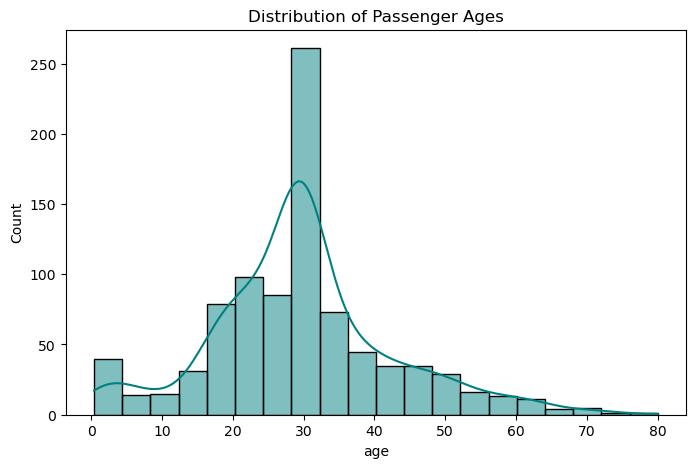

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True, color="teal")
plt.title("Distribution of Passenger Ages") # [cite: 50]
plt.savefig("Distribution of Passenger Ages.png")
plt.show() # [cite: 51]

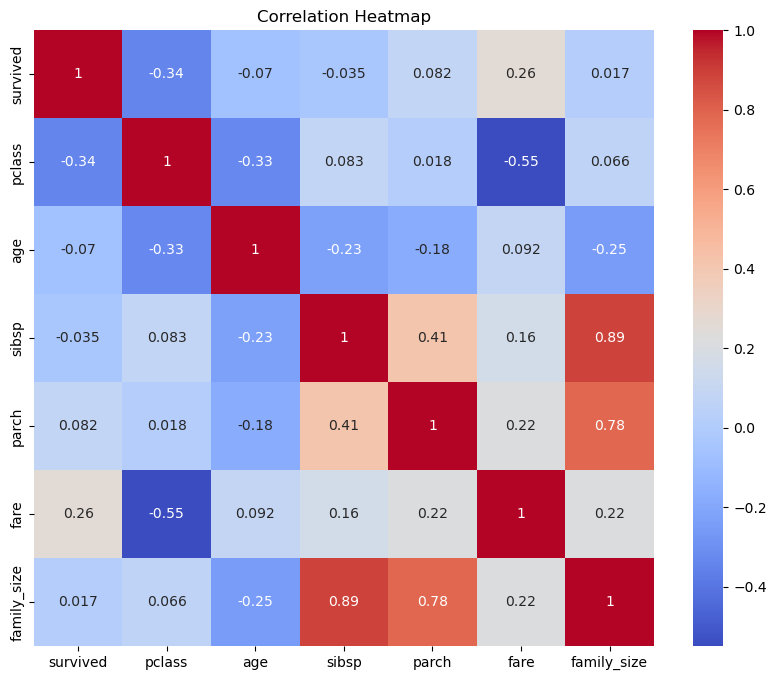

In [9]:
plt.figure(figsize=(10, 8))
# Numeric correlation only [cite: 53]
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap") # [cite: 54]
plt.savefig("Correlation Heatmap.png")
plt.show() # [cite: 55]

C:\Users\CPS\AppData\Local\Temp\ipykernel_9004\1460311063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="family_size", y="survived", data=df, palette="viridis") # [cite: 59]


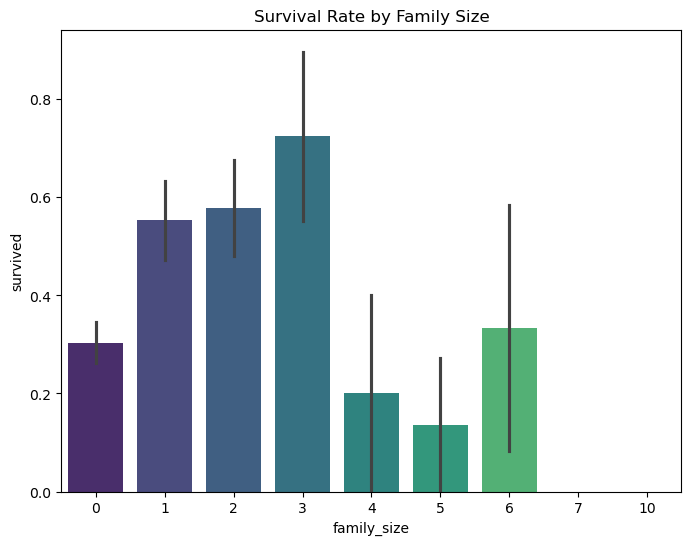

In [10]:
plt.figure(figsize=(8, 6))
sns.barplot(x="family_size", y="survived", data=df, palette="viridis") # [cite: 59]
plt.title("Survival Rate by Family Size") # [cite: 60]
plt.savefig("Survival Rate by Family Size.png")
plt.show() # [cite: 61]